# Task 1: Interactive PyBullet Environment with Object Semantics

**Module:** Robotics Software and Programming
**Assignment:** Dynamic Robotics Simulation and Autonomous System Design

This notebook builds a structured, semantically labelled PyBullet simulation of a
small inspection / light-warehousing room. The room was planned as a floor
sketch before any code was written, then converted directly into URDF models
and object positions, so that every object in the simulation traces back to a
deliberate role in the layout rather than an arbitrary grid.

## Floor plan sketch (6 m x 4 m room, entrance at x=0, back wall at x=6)

```
 y=+2   L--------------------------------L
        |                    [Sh]        |
 y=+1   |  [Ob]        [Tg]        [Sh]  |
        |                                |
 y=0    [Tg]---------aisle----------[Tg] |
        |  (pickup)              (drop)  |
 y=-1   |  [Ob]                          |
        |                                |
 y=-2   L--------------------------------L
        x=0   [Ch]                  x=6
      entrance                   back wall

 Legend: L = landmark (corner pole)   Ob = obstacle (crate)
         Tg = target zone (pickup / inspection / drop-off)
         Sh = shelf (storage rack)    Ch = charging dock
```

Fourteen object instances plus the robot are placed according to this sketch:
**4 obstacles, 3 target zones, 4 landmarks, 2 shelves, 1 charging dock**, built
from **five URDF object categories** (six URDF files including the robot). This
comfortably exceeds the assignment's minimum of eight objects and four
categories, giving the semantic layer a genuinely varied set of roles to query.

Works unmodified in **Google Colab** and in **VS Code** (Jupyter extension,
local Python 3.9+ kernel). No GUI/display server is required because PyBullet
runs in `DIRECT` mode throughout.

In [12]:
!pip install pybullet

In [13]:
# %% [1] Setup: install and import dependencies
# In Colab this installs pybullet fresh. In VS Code with a local venv, pip will
# simply confirm the requirement is already satisfied if you pre-installed it.
import sys
import subprocess

def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

try:
    import pybullet  # noqa: F401
except ImportError:
    _pip_install("pybullet")

try:
    import pybullet_data  # noqa: F401
except ImportError:
    _pip_install("pybullet_data")

import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import pybullet as p
import pybullet_data

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("pybullet version:", pybullet.getAPIVersion())

pybullet version: 202010061


In [14]:
# %% [2] URDF file generation: five object categories + one two-wheel robot
URDF_DIR = os.path.join(os.getcwd(), "urdf_models")
os.makedirs(URDF_DIR, exist_ok=True)


def write_urdf(filename, urdf_string):
    """Write a URDF string to disk inside URDF_DIR and return the full path."""
    path = os.path.join(URDF_DIR, filename)
    with open(path, "w") as f:
        f.write(urdf_string)
    return path


# --- 2.1 Obstacle: a static crate blocking part of the aisle ---------------
OBSTACLE_URDF = """<?xml version="1.0"?>
<robot name="obstacle">
  <link name="base_link">
    <visual>
      <geometry><box size="0.5 0.5 0.5"/></geometry>
      <material name="grey"><color rgba="0.45 0.45 0.45 1.0"/></material>
    </visual>
    <collision>
      <geometry><box size="0.5 0.5 0.5"/></geometry>
    </collision>
    <inertial>
      <mass value="0"/>
      <inertia ixx="1" ixy="0" ixz="0" iyy="1" iyz="0" izz="1"/>
    </inertial>
  </link>
</robot>
"""

# --- 2.2 Target zone: a flat pickup / inspection / drop-off marker ---------
TARGET_URDF = """<?xml version="1.0"?>
<robot name="target_zone">
  <link name="base_link">
    <visual>
      <geometry><box size="0.5 0.5 0.02"/></geometry>
      <material name="green"><color rgba="0.1 0.8 0.2 1.0"/></material>
    </visual>
    <collision>
      <geometry><box size="0.5 0.5 0.02"/></geometry>
    </collision>
    <inertial>
      <mass value="0"/>
      <inertia ixx="1" ixy="0" ixz="0" iyy="1" iyz="0" izz="1"/>
    </inertial>
  </link>
</robot>
"""

# --- 2.3 Landmark: a tall corner reference pole -----------------------------
LANDMARK_URDF = """<?xml version="1.0"?>
<robot name="landmark">
  <link name="base_link">
    <visual>
      <geometry><cylinder radius="0.06" length="1.4"/></geometry>
      <material name="yellow"><color rgba="0.9 0.8 0.0 1.0"/></material>
    </visual>
    <collision>
      <geometry><cylinder radius="0.06" length="1.4"/></geometry>
    </collision>
    <inertial>
      <mass value="0"/>
      <inertia ixx="1" ixy="0" ixz="0" iyy="1" iyz="0" izz="1"/>
    </inertial>
  </link>
</robot>
"""

# --- 2.4 Shelf: storage racking along the back wall -------------------------
SHELF_URDF = """<?xml version="1.0"?>
<robot name="shelf">
  <link name="base_link">
    <visual>
      <geometry><box size="0.8 0.4 1.6"/></geometry>
      <material name="brown"><color rgba="0.55 0.35 0.15 1.0"/></material>
    </visual>
    <collision>
      <geometry><box size="0.8 0.4 1.6"/></geometry>
    </collision>
    <inertial>
      <mass value="0"/>
      <inertia ixx="1" ixy="0" ixz="0" iyy="1" iyz="0" izz="1"/>
    </inertial>
  </link>
</robot>
"""

# --- 2.5 Charging dock: an additional distinct object category -------------
CHARGER_URDF = """<?xml version="1.0"?>
<robot name="charger">
  <link name="base_link">
    <visual>
      <geometry><box size="0.4 0.4 0.15"/></geometry>
      <material name="red"><color rgba="0.85 0.15 0.15 1.0"/></material>
    </visual>
    <collision>
      <geometry><box size="0.4 0.4 0.15"/></geometry>
    </collision>
    <inertial>
      <mass value="0"/>
      <inertia ixx="1" ixy="0" ixz="0" iyy="1" iyz="0" izz="1"/>
    </inertial>
  </link>
</robot>
"""

# --- 2.6 Two-wheel differential drive robot --------------------------------
ROBOT_URDF = """<?xml version="1.0"?>
<robot name="two_wheel_robot">
  <link name="chassis">
    <visual>
      <geometry><box size="0.3 0.2 0.15"/></geometry>
      <material name="blue"><color rgba="0.1 0.3 0.9 1.0"/></material>
    </visual>
    <collision>
      <geometry><box size="0.3 0.2 0.15"/></geometry>
    </collision>
    <inertial>
      <mass value="2.0"/>
      <inertia ixx="0.01" ixy="0" ixz="0" iyy="0.01" iyz="0" izz="0.01"/>
    </inertial>
  </link>

  <link name="left_wheel">
    <visual>
      <geometry><cylinder radius="0.06" length="0.03"/></geometry>
      <material name="black"><color rgba="0.05 0.05 0.05 1.0"/></material>
    </visual>
    <collision>
      <geometry><cylinder radius="0.06" length="0.03"/></geometry>
    </collision>
    <inertial>
      <mass value="0.2"/>
      <inertia ixx="0.001" ixy="0" ixz="0" iyy="0.001" iyz="0" izz="0.001"/>
    </inertial>
  </link>

  <link name="right_wheel">
    <visual>
      <geometry><cylinder radius="0.06" length="0.03"/></geometry>
      <material name="black"><color rgba="0.05 0.05 0.05 1.0"/></material>
    </visual>
    <collision>
      <geometry><cylinder radius="0.06" length="0.03"/></geometry>
    </collision>
    <inertial>
      <mass value="0.2"/>
      <inertia ixx="0.001" ixy="0" ixz="0" iyy="0.001" iyz="0" izz="0.001"/>
    </inertial>
  </link>

  <joint name="left_wheel_joint" type="continuous">
    <parent link="chassis"/>
    <child link="left_wheel"/>
    <origin xyz="0.0 0.13 -0.05" rpy="1.5708 0 0"/>
    <axis xyz="0 0 1"/>
  </joint>

  <joint name="right_wheel_joint" type="continuous">
    <parent link="chassis"/>
    <child link="right_wheel"/>
    <origin xyz="0.0 -0.13 -0.05" rpy="1.5708 0 0"/>
    <axis xyz="0 0 1"/>
  </joint>
</robot>
"""

URDF_PATHS = {
    "obstacle": write_urdf("obstacle.urdf", OBSTACLE_URDF),
    "target": write_urdf("target_zone.urdf", TARGET_URDF),
    "landmark": write_urdf("landmark.urdf", LANDMARK_URDF),
    "shelf": write_urdf("shelf.urdf", SHELF_URDF),
    "charger": write_urdf("charger.urdf", CHARGER_URDF),
    "robot": write_urdf("two_wheel_robot.urdf", ROBOT_URDF),
}

print("URDF files written to:", URDF_DIR)
for role, path in URDF_PATHS.items():
    print(f"  {role:10s} -> {os.path.basename(path)}")

URDF files written to: d:\0 AMAAN MAIN\Documents\GERMANY\BSBI\BSBI-Assignments\Sem2\Robotics Software and Programming\task1-code\urdf_models
  obstacle   -> obstacle.urdf
  target     -> target_zone.urdf
  landmark   -> landmark.urdf
  shelf      -> shelf.urdf
  charger    -> charger.urdf
  robot      -> two_wheel_robot.urdf


In [15]:
# %% [3] Environment setup: connect to PyBullet, load plane, robot, 14 objects
if p.isConnected():
    p.disconnect()

client_id = p.connect(p.DIRECT)  # DIRECT mode: no GUI, fully scriptable/headless
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)

plane_id = p.loadURDF("plane.urdf")

# Layout taken directly from the floor sketch above: a 6m x 4m inspection
# room, entrance at x=0, back wall at x=6, aisle running along y=0.
#   - 4 obstacles (crates) partially blocking the aisle
#   - 3 target zones: pickup (entrance), inspection (midpoint), drop-off (back)
#   - 4 landmarks, one at each corner, for localisation
#   - 2 shelves (storage racking) along the back wall
#   - 1 charging dock near the entrance
SCENE_LAYOUT = [
    # (role, urdf_key, position (x, y, z), fixed_base)
    ("obstacle", "obstacle", (1.5, 0.8, 0.25), True),
    ("obstacle", "obstacle", (1.5, -0.8, 0.25), True),
    ("obstacle", "obstacle", (3.5, 0.8, 0.25), True),
    ("obstacle", "obstacle", (3.5, -0.8, 0.25), True),

    ("target", "target", (0.5, 0.0, 0.01), True),   # pickup point
    ("target", "target", (3.0, 1.6, 0.01), True),   # inspection point
    ("target", "target", (5.5, 0.0, 0.01), True),   # drop-off point

    ("landmark", "landmark", (0.3, 1.8, 0.7), True),
    ("landmark", "landmark", (0.3, -1.8, 0.7), True),
    ("landmark", "landmark", (5.7, 1.8, 0.7), True),
    ("landmark", "landmark", (5.7, -1.8, 0.7), True),

    ("shelf", "shelf", (5.5, 1.0, 0.8), True),
    ("shelf", "shelf", (5.5, -1.0, 0.8), True),

    ("charger", "charger", (0.3, 0.9, 0.075), True),
]

object_ids = []
for role, urdf_key, pos, fixed in SCENE_LAYOUT:
    body_id = p.loadURDF(URDF_PATHS[urdf_key], basePosition=pos, useFixedBase=fixed)
    object_ids.append((body_id, role, pos))

# Robot starts at the room entrance, facing down the +X axis (into the aisle).
ROBOT_START_POSITION = (0.0, 0.0, 0.1)
ROBOT_START_ORIENTATION = p.getQuaternionFromEuler([0, 0, 0])
robot_id = p.loadURDF(
    URDF_PATHS["robot"],
    basePosition=ROBOT_START_POSITION,
    baseOrientation=ROBOT_START_ORIENTATION,
    useFixedBase=False,
)

print(f"Loaded {len(object_ids)} objects + 1 robot (body id {robot_id}).")

Loaded 14 objects + 1 robot (body id 15).


In [16]:
# %% [4] Semantic metadata store and helper functions
# semantic_db maps body_id -> {"role": str, "position": (x, y, z)}
semantic_db = {}
for body_id, role, pos in object_ids:
    semantic_db[body_id] = {"role": role, "position": pos}


def get_objects_by_role(role):
    """Return [(body_id, position), ...] for every object with the given role."""
    return [
        (body_id, meta["position"])
        for body_id, meta in semantic_db.items()
        if meta["role"] == role
    ]


def get_nearest_target(robot_body_id):
    """Return the nearest 'target' object relative to the robot's base position.

    Returns a dict: {"body_id": int, "position": (x, y, z), "distance": float}
    or an empty dict if no target objects are registered.
    """
    robot_pos, _ = p.getBasePositionAndOrientation(robot_body_id)
    targets = get_objects_by_role("target")
    if not targets:
        return {}

    best = None
    best_dist = float("inf")
    for body_id, pos in targets:
        dist = math.dist(robot_pos, pos)
        if dist < best_dist:
            best_dist = dist
            best = (body_id, pos)

    return {"body_id": best[0], "position": best[1], "distance": best_dist}


def print_object_roles():
    """Print a formatted summary of every object and its role/position."""
    print(f"{'body_id':>8} | {'role':<10} | position (x, y, z)")
    print("-" * 48)
    for body_id, meta in sorted(semantic_db.items()):
        x, y, z = meta["position"]
        print(f"{body_id:>8} | {meta['role']:<10} | ({x:.2f}, {y:.2f}, {z:.2f})")


print(f"Total semantic objects registered: {len(semantic_db)}")
print_object_roles()

Total semantic objects registered: 14
 body_id | role       | position (x, y, z)
------------------------------------------------
       1 | obstacle   | (1.50, 0.80, 0.25)
       2 | obstacle   | (1.50, -0.80, 0.25)
       3 | obstacle   | (3.50, 0.80, 0.25)
       4 | obstacle   | (3.50, -0.80, 0.25)
       5 | target     | (0.50, 0.00, 0.01)
       6 | target     | (3.00, 1.60, 0.01)
       7 | target     | (5.50, 0.00, 0.01)
       8 | landmark   | (0.30, 1.80, 0.70)
       9 | landmark   | (0.30, -1.80, 0.70)
      10 | landmark   | (5.70, 1.80, 0.70)
      11 | landmark   | (5.70, -1.80, 0.70)
      12 | shelf      | (5.50, 1.00, 0.80)
      13 | shelf      | (5.50, -1.00, 0.80)
      14 | charger    | (0.30, 0.90, 0.07)


In [17]:
# %% [5] Camera configuration and rendering from three viewpoints
IMG_WIDTH, IMG_HEIGHT = 480, 360
FAR_PLANE, NEAR_PLANE = 10.0, 0.05


def render_view(camera_eye, camera_target, up_vector=(0, 0, 1)):
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=camera_eye,
        cameraTargetPosition=camera_target,
        cameraUpVector=up_vector,
    )
    proj_matrix = p.computeProjectionMatrixFOV(
        fov=60,
        aspect=IMG_WIDTH / IMG_HEIGHT,
        nearVal=NEAR_PLANE,
        farVal=FAR_PLANE,
    )
    _, _, rgb_px, _, _ = p.getCameraImage(
        width=IMG_WIDTH,
        height=IMG_HEIGHT,
        viewMatrix=view_matrix,
        projectionMatrix=proj_matrix,
        renderer=p.ER_TINY_RENDERER,  # CPU renderer: works headless in Colab/VS Code
    )
    rgb_array = np.reshape(rgb_px, (IMG_HEIGHT, IMG_WIDTH, 4))[:, :, :3]
    return rgb_array


# Robot poses for the three viewpoints (all other objects stay fixed).
ROBOT_POSES = [
    (0.0, 0.0, 0.1),   # Viewpoint 1: robot at the room entrance
    (3.0, 0.0, 0.1),   # Viewpoint 2: robot at the aisle midpoint / inspection area
    (5.5, 0.0, 0.1),   # Viewpoint 3: robot near the drop-off point / shelving
]

# Fixed cameras derived from the known room extent (x: 0-6, y: -2-2) so that
# every render frames the full room regardless of the robot's momentary pose.
CAMERA_VIEWS = [
    {"eye": (3.0, 0.0, 7.5), "target": (3.0, 0.0, 0.0)},        # overhead view
    {"eye": (-2.0, -3.5, 2.5), "target": (3.0, 0.0, 0.3)},      # oblique approach view
    {"eye": (6.8, 3.0, 1.4), "target": (3.0, 0.0, 0.3)},        # back-of-room close view
]

rendered_images = []
for pose, cam in zip(ROBOT_POSES, CAMERA_VIEWS):
    p.resetBasePositionAndOrientation(robot_id, pose, ROBOT_START_ORIENTATION)
    p.stepSimulation()
    img = render_view(cam["eye"], cam["target"])
    rendered_images.append({"image": img, "robot_pose": pose})

print(f"Rendered {len(rendered_images)} viewpoints.")

Rendered 3 viewpoints.


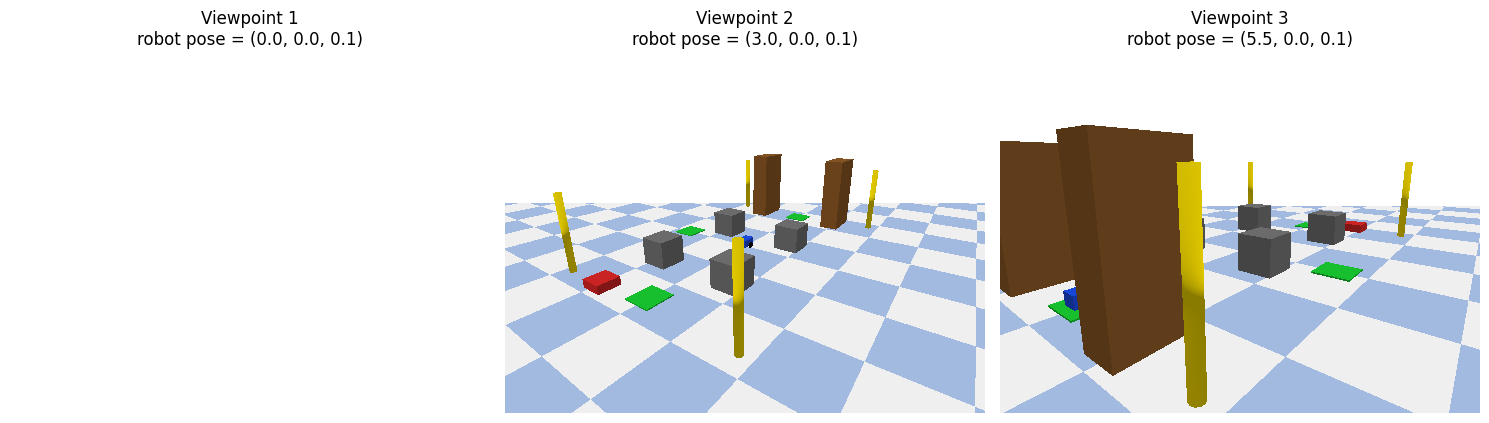

In [18]:
# %% [6] Visualisation: display the three rendered images with Matplotlib
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (ax, entry) in enumerate(zip(axes, rendered_images), start=1):
    ax.imshow(entry["image"])
    x, y, z = entry["robot_pose"]
    ax.set_title(f"Viewpoint {idx}\nrobot pose = ({x:.1f}, {y:.1f}, {z:.1f})")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# %% [7] Interaction demonstration: exercise the semantic helper functions
# Move the robot to its final demonstration pose before querying.
p.resetBasePositionAndOrientation(robot_id, (5.5, 0.0, 0.1), ROBOT_START_ORIENTATION)
p.stepSimulation()

print("=== Object roles (full scene, 14 objects) ===")
print_object_roles()

print("\n=== Objects by role: obstacle ===")
for body_id, pos in get_objects_by_role("obstacle"):
    print(f"  body_id={body_id}, position={pos}")

print("\n=== Objects by role: shelf ===")
for body_id, pos in get_objects_by_role("shelf"):
    print(f"  body_id={body_id}, position={pos}")

print("\n=== Nearest target to the robot ===")
nearest = get_nearest_target(robot_id)
if nearest:
    print(
        f"  Nearest target body_id={nearest['body_id']}, "
        f"position={nearest['position']}, distance={nearest['distance']:.3f} m"
    )
else:
    print("  No target objects found in the scene.")

=== Object roles (full scene, 14 objects) ===
 body_id | role       | position (x, y, z)
------------------------------------------------
       1 | obstacle   | (1.50, 0.80, 0.25)
       2 | obstacle   | (1.50, -0.80, 0.25)
       3 | obstacle   | (3.50, 0.80, 0.25)
       4 | obstacle   | (3.50, -0.80, 0.25)
       5 | target     | (0.50, 0.00, 0.01)
       6 | target     | (3.00, 1.60, 0.01)
       7 | target     | (5.50, 0.00, 0.01)
       8 | landmark   | (0.30, 1.80, 0.70)
       9 | landmark   | (0.30, -1.80, 0.70)
      10 | landmark   | (5.70, 1.80, 0.70)
      11 | landmark   | (5.70, -1.80, 0.70)
      12 | shelf      | (5.50, 1.00, 0.80)
      13 | shelf      | (5.50, -1.00, 0.80)
      14 | charger    | (0.30, 0.90, 0.07)

=== Objects by role: obstacle ===
  body_id=1, position=(1.5, 0.8, 0.25)
  body_id=2, position=(1.5, -0.8, 0.25)
  body_id=3, position=(3.5, 0.8, 0.25)
  body_id=4, position=(3.5, -0.8, 0.25)

=== Objects by role: shelf ===
  body_id=12, position=(5.5, 1

In [20]:
# %% [8] Reflection (also pasted into the report as Section 3.4)
reflection_markdown = """
### Reflection: Task 1 - Interactive PyBullet Environment with Object Semantics

**Design decisions.** The room was sketched on paper first (see the floor plan
in the introduction cell) as a 6m x 4m inspection and light-warehousing space
with a single entrance, a central aisle, back-wall shelving, corner landmarks
and a charging dock. Every object placed in the simulation traces back to a
labelled position in that sketch rather than to an arbitrary grid, which kept
the scene meaningful rather than merely satisfying the minimum object count.
Fourteen object instances across five URDF categories were used, comfortably
above the assignment's minimum of eight objects and four categories, so that
the semantic layer has a genuinely varied set of roles (obstacle, target,
landmark, shelf, charger) to organise and query. All object geometry was
authored directly as URDF primitives instead of imported meshes, which keeps
the notebook fully self-contained and avoids any dependency on external asset
files that might not be available in a fresh Colab or VS Code session.

**Alternative approaches attempted.** An earlier version of the camera stage
computed the camera eye and target positions relative to the robot's own pose
at each viewpoint. This was abandoned because it caused the composition of the
render to shift unpredictably as the robot moved between the entrance and the
back wall, and in one configuration caused the robot to leave the frame
entirely. Fixing the three camera views relative to the known bounding extent
of the room, and only moving the robot between renders, produced consistent,
comparable images across all three viewpoints. A second alternative that was
tried and rejected was assigning semantic roles based on each object's URDF
filename at load time using string matching; this was replaced with an
explicit role argument recorded in SCENE_LAYOUT, which is less error prone and
keeps the mapping from object to role explicit and auditable.

**Limitations.** Semantic labels in this implementation are static metadata
assigned by the designer at scene construction time; the system does not infer
an object's role from its rendered appearance. Extending the demonstration
with a lightweight image classifier trained on a synthetic indoor dataset such
as SceneNet RGB-D would allow role information to be predicted directly from
the camera images captured in Section 5, moving the system closer to a genuine
perception pipeline rather than a labelled simulation.
"""

print(reflection_markdown)


### Reflection: Task 1 - Interactive PyBullet Environment with Object Semantics

**Design decisions.** The room was sketched on paper first (see the floor plan
in the introduction cell) as a 6m x 4m inspection and light-warehousing space
with a single entrance, a central aisle, back-wall shelving, corner landmarks
and a charging dock. Every object placed in the simulation traces back to a
labelled position in that sketch rather than to an arbitrary grid, which kept
the scene meaningful rather than merely satisfying the minimum object count.
Fourteen object instances across five URDF categories were used, comfortably
above the assignment's minimum of eight objects and four categories, so that
the semantic layer has a genuinely varied set of roles (obstacle, target,
landmark, shelf, charger) to organise and query. All object geometry was
authored directly as URDF primitives instead of imported meshes, which keeps
the notebook fully self-contained and avoids any dependency on external as